## Decision Tree
Train a decision tree on the original census data using the same preprocessing pipeline style as the other notebooks.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from copy import deepcopy

from utils.modeling_common import (
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
    build_tabular_preprocess,
    load_adult_dataframe,
    split_features_target,
    split_train_test
)
from utils.evaluation_utils import ensure_dir
from utils.notebook_plotting_utils import plot_confusion_matrix, plot_metrics_bar_chart

In [2]:
df = load_adult_dataframe("census+income/adult.data")
X, y = split_features_target(df)

In [3]:
numeric_features = list(NUMERIC_FEATURES)
categorical_features = list(CATEGORICAL_FEATURES)

preprocess = build_tabular_preprocess()

In [4]:
X_train, X_test, y_train, y_test = split_train_test(
    X,
    y,
    test_size=0.25,
    random_state=11,
)

tree_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("tree", DecisionTreeClassifier(max_depth=10, random_state=11))
])

tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)
y_proba_tree = tree_model.predict_proba(X_test)[:, 1]

tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_cm = confusion_matrix(y_test, y_pred_tree)

print("Decision Tree Accuracy:", tree_accuracy)
print("\nDecision Tree confusion matrix:\n", tree_cm)
print("\nDecision Tree classification report:\n", classification_report(y_test, y_pred_tree))

# Export confusion matrix and probabilities for later comparison
ensure_dir(Path("exports"))
dt_cm_path = os.path.join("exports", "decision_tree_confusion_matrix.csv")
np.savetxt(dt_cm_path, tree_cm, fmt="%d", delimiter=",")

dt_probs_path = os.path.join("exports", "decision_tree_probs.csv")
np.savetxt(dt_probs_path, np.column_stack([y_test.to_numpy(), y_proba_tree]), delimiter=",")

print(f"Saved Decision Tree confusion matrix to: {dt_cm_path}")
print(f"Saved Decision Tree probabilities to: {dt_probs_path}")

Decision Tree Accuracy: 0.8568971870777545

Decision Tree confusion matrix:
 [[5864  317]
 [ 848 1112]]

Decision Tree classification report:
               precision    recall  f1-score   support

           0       0.87      0.95      0.91      6181
           1       0.78      0.57      0.66      1960

    accuracy                           0.86      8141
   macro avg       0.83      0.76      0.78      8141
weighted avg       0.85      0.86      0.85      8141

Saved Decision Tree confusion matrix to: exports\decision_tree_confusion_matrix.csv
Saved Decision Tree probabilities to: exports\decision_tree_probs.csv


In [5]:
processed_feature_names = tree_model.named_steps["preprocess"].get_feature_names_out()
importances = tree_model.named_steps["tree"].feature_importances_

feature_importance_df = pd.DataFrame({
    "processed_feature": processed_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("Top processed feature importances:")
print(feature_importance_df.head(20).to_string(index=False))

def tree_original_column(processed_feature_name):
    suffix = processed_feature_name.split("__", 1)[-1]

    if suffix in numeric_features:
        return suffix

    for col in sorted(categorical_features, key=len, reverse=True):
        if suffix == col or suffix.startswith(f"{col}_"):
            return col

    return suffix

feature_importance_df["original_column"] = feature_importance_df["processed_feature"].apply(tree_original_column)
column_importance_df = (
    feature_importance_df
    .groupby("original_column", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

print("\nGrouped feature importances by original column:")
print(column_importance_df.to_string(index=False))

Top processed feature importances:
                     processed_feature  importance
cat__marital_status_Married-civ-spouse    0.376453
                    num__education_num    0.208025
                     num__capital_gain    0.190990
                     num__capital_loss    0.071644
                              num__age    0.050839
                   num__hours_per_week    0.035872
       cat__occupation_Exec-managerial    0.007343
         cat__occupation_Other-service    0.007320
       cat__workclass_Self-emp-not-inc    0.006148
                cat__relationship_Wife    0.004605
        cat__occupation_Prof-specialty    0.003412
                       cat__sex_Female    0.002766
       cat__occupation_Farming-fishing    0.002605
              cat__workclass_State-gov    0.002403
                cat__workclass_Private    0.002240
     cat__native_country_United-States    0.001939
              cat__workclass_Local-gov    0.001936
            cat__education_Prof-school    0.001

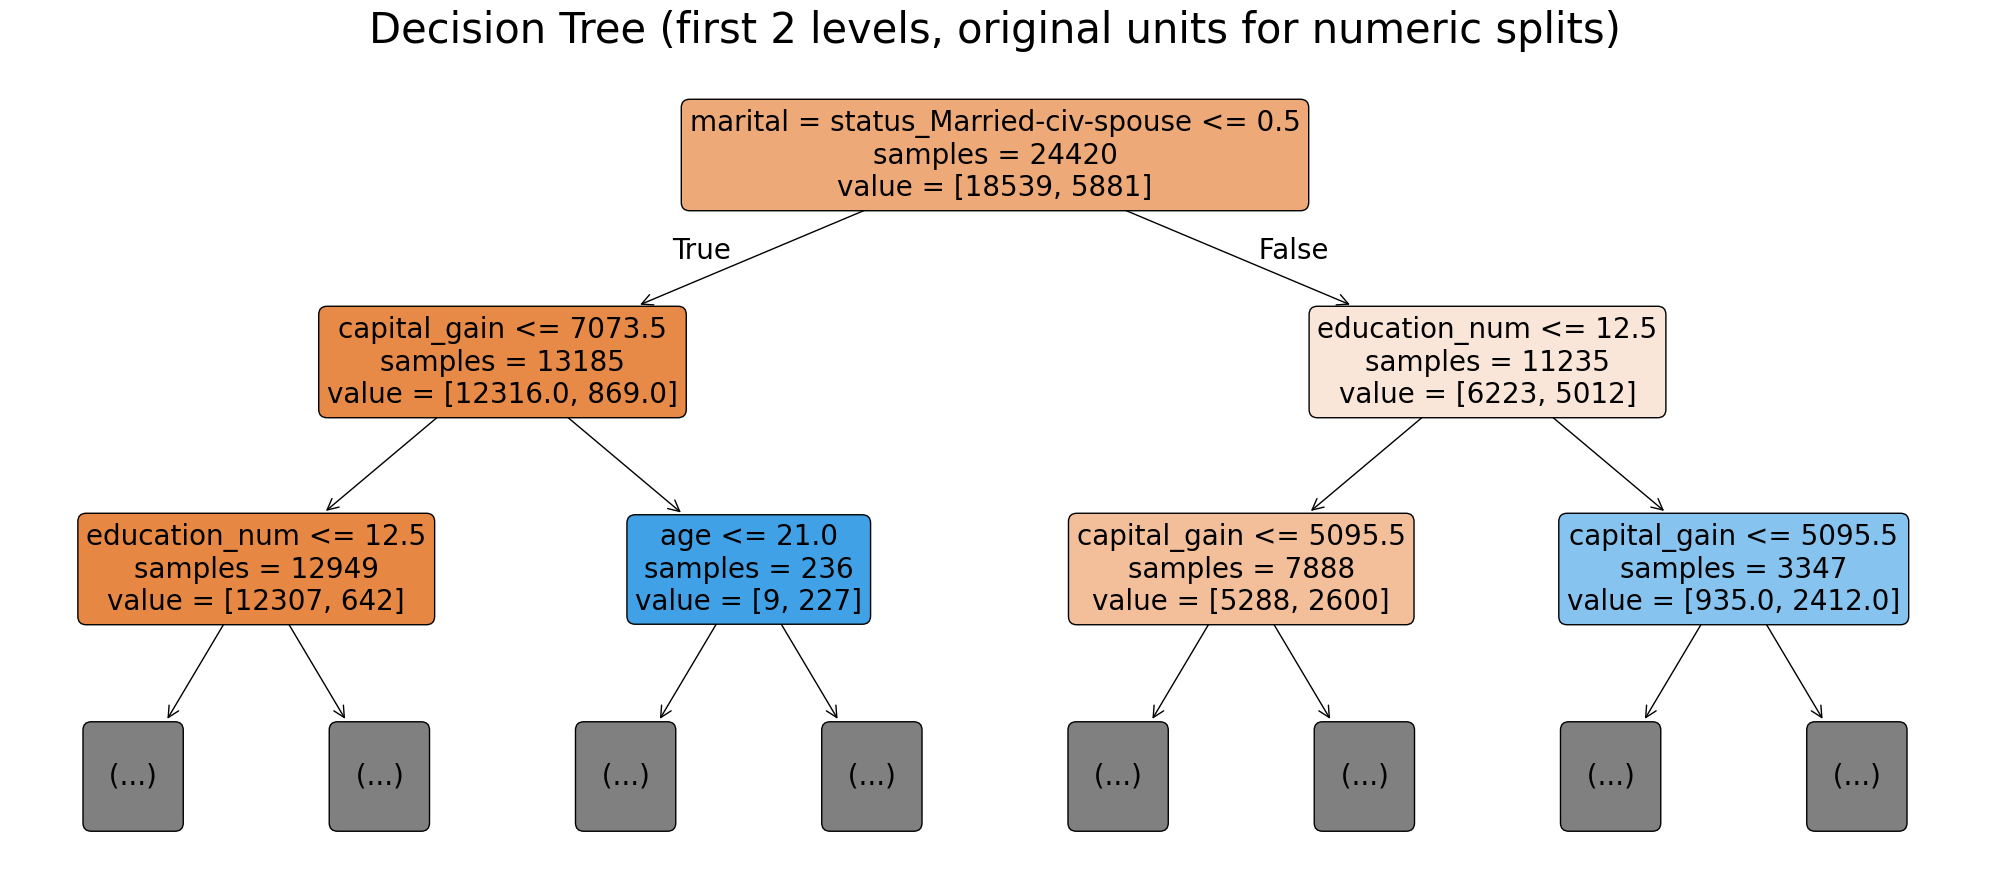

In [6]:
# Make a display-only copy of the tree with numeric split thresholds converted
# back to the original feature scale.
display_tree = deepcopy(tree_model.named_steps["tree"])
scaler = tree_model.named_steps["preprocess"].named_transformers_["num"].named_steps["scaler"]
processed_feature_names = tree_model.named_steps["preprocess"].get_feature_names_out()

def pretty_feature_name(processed_feature_name):
    suffix = processed_feature_name.split("__", 1)[-1]

    if suffix in numeric_features:
        return suffix

    if "_" in suffix:
        original_column, category = suffix.split("_", 1)
        return f"{original_column} = {category}"

    return suffix

for node_index in range(display_tree.tree_.node_count):
    feature_index = display_tree.tree_.feature[node_index]
    if feature_index < 0:
        continue

    processed_name = processed_feature_names[feature_index]
    original_name = processed_name.split("__", 1)[-1]

    if original_name in numeric_features:
        numeric_index = numeric_features.index(original_name)
        display_tree.tree_.threshold[node_index] = (
            display_tree.tree_.threshold[node_index] * scaler.scale_[numeric_index]
            + scaler.mean_[numeric_index]
        )

plt.figure(figsize=(20, 9))
plot_tree(
    display_tree,
    feature_names=[pretty_feature_name(name) for name in processed_feature_names],
    filled=True,
    max_depth=2,
    fontsize=20,
    impurity=False,
    rounded=True
)
plt.title("Decision Tree (first 2 levels, original units for numeric splits)", fontsize=30)
plt.tight_layout()
plt.show()

Decision Tree Accuracy: 0.8568971870777545

Decision Tree confusion matrix:
 [[5864  317]
 [ 848 1112]]

Decision Tree classification report:
               precision    recall  f1-score   support

           0       0.87      0.95      0.91      6181
           1       0.78      0.57      0.66      1960

    accuracy                           0.86      8141
   macro avg       0.83      0.76      0.78      8141
weighted avg       0.85      0.86      0.85      8141



,class,precision,recall
0,0,0.873659,0.948714
1,1,0.778167,0.567347


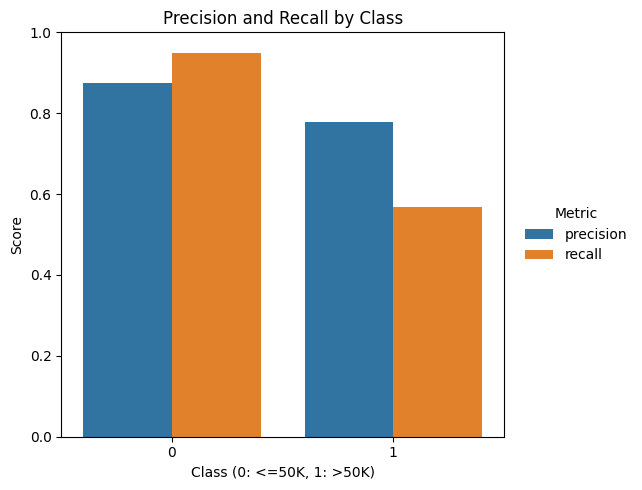

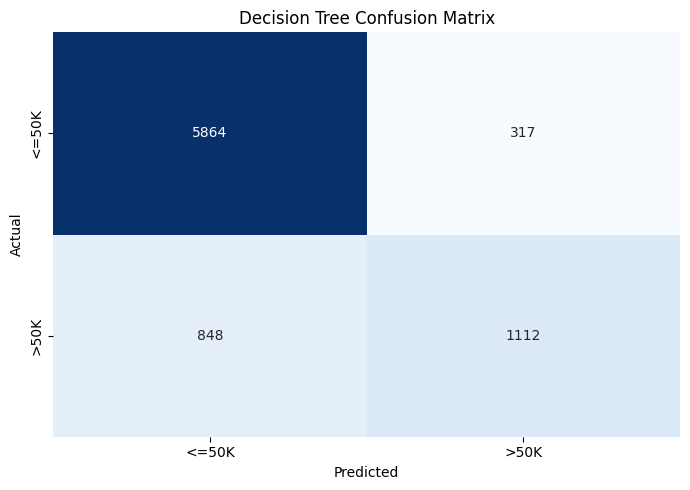

In [7]:
tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_cm = confusion_matrix(y_test, y_pred_tree)
print(f"Decision Tree Accuracy: {tree_accuracy}\n")
print(f"Decision Tree confusion matrix:\n {tree_cm}\n")
print(f"Decision Tree classification report:\n {classification_report(y_test, y_pred_tree)}")

# Visualize precision and recall (using shared utility)
report_dict = classification_report(y_test, y_pred_tree, output_dict=True)
report_df = pd.DataFrame(report_dict).T

class_rows = [str(c) for c in sorted(set(y_test))]
metrics_df = report_df.loc[class_rows, ["precision", "recall"]].reset_index()
metrics_df = metrics_df.rename(columns={"index": "class"})
metrics_long = metrics_df.melt(id_vars="class", var_name="metric", value_name="score")

display(metrics_df)
plot_metrics_bar_chart(metrics_long)

# Confusion matrix heat map (using shared utility)
plot_confusion_matrix(tree_cm, title="Decision Tree Confusion Matrix")

In [8]:
# Export matrix and probabilities for cross-model comparison plots.
ensure_dir(Path("exports"))
dt_cm_path = os.path.join("exports", "decision_tree_confusion_matrix.csv")
np.savetxt(dt_cm_path, tree_cm, fmt="%d", delimiter=",")

dt_probs_path = os.path.join("exports", "decision_tree_probs.csv")
np.savetxt(dt_probs_path, np.column_stack([y_test.to_numpy(), y_proba_tree]), delimiter=",")

print(f"Saved Decision Tree confusion matrix to: {dt_cm_path}")
print(f"Saved Decision Tree probabilities to: {dt_probs_path}")

Saved Decision Tree confusion matrix to: exports\decision_tree_confusion_matrix.csv
Saved Decision Tree probabilities to: exports\decision_tree_probs.csv
